# 2026 07 16 Python 실습코드

In [60]:
# 기본 셋업 (맨 처음 한 번 실행)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib                 # 그래프 한글 폰트 자동 적용
plt.rcParams['axes.unicode_minus'] = False  # 음수 부호 깨짐 방지

print("준비 완료 - numpy", np.__version__, "/ pandas", pd.__version__, "/ seaborn", sns.__version__)


준비 완료 - numpy 2.5.1 / pandas 3.0.3 / seaborn 0.13.2


In [61]:
# Mile per Gallon에 대한 정보
df = sns.load_dataset("mpg")
print(df.info())
df

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 35.9 KB
None


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [62]:
# DataFrame의 통계정보
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


<Axes: xlabel='weight', ylabel='acceleration'>

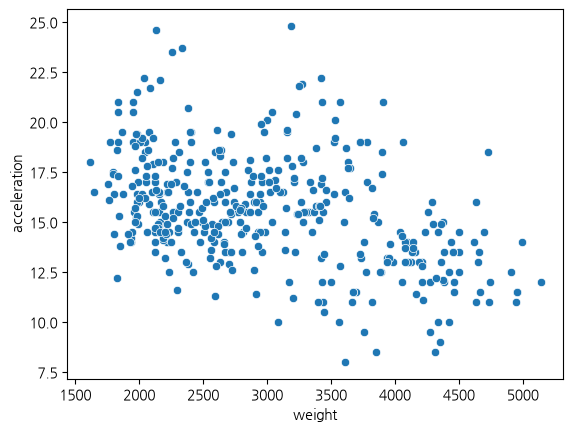

In [63]:
sns.scatterplot(data = df, x = "weight", y = 'acceleration')

<Axes: xlabel='weight', ylabel='acceleration'>

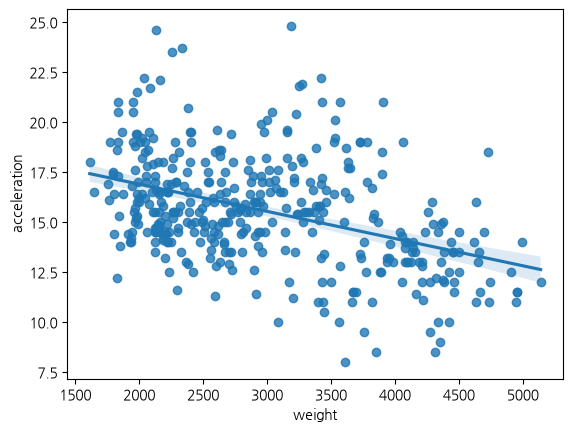

In [64]:
sns.regplot(data = df, x = 'weight', y = 'acceleration')

<Axes: >

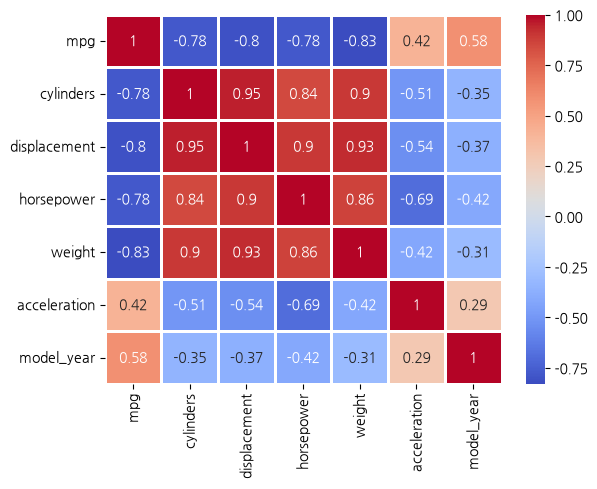

In [65]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot = True, cmap = 'coolwarm', linewidths=1)

<Axes: xlabel='weight', ylabel='Count'>

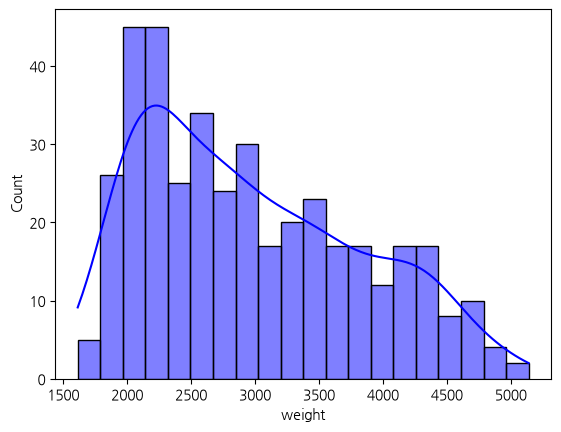

In [66]:
sns.histplot(df["weight"], bins = 20, kde = True, color = 'blue')

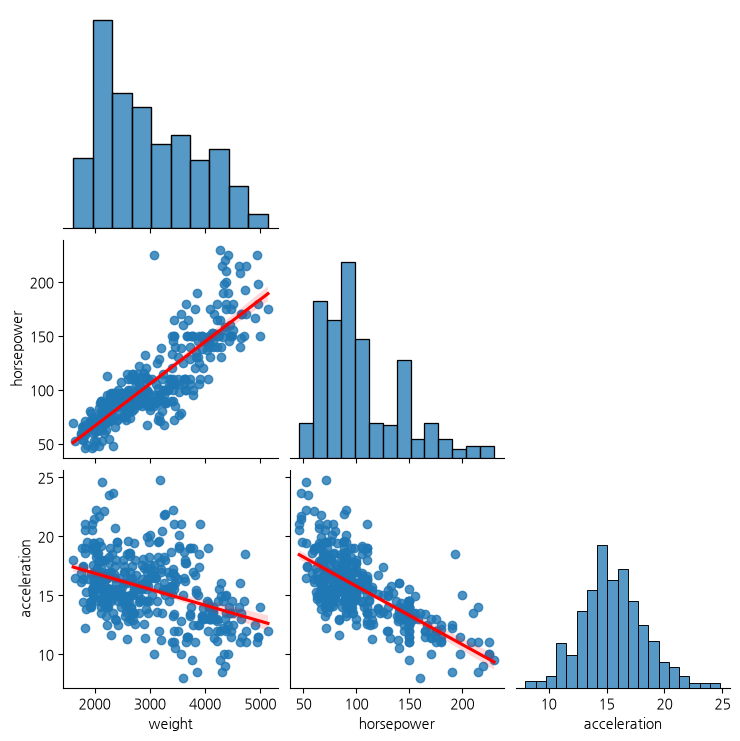

In [67]:
df = df.dropna(subset = ['horsepower'])
sns.pairplot(df[['weight', 'horsepower', 'acceleration']], corner = True, kind = 'reg', plot_kws = {'line_kws' : {'color' : 'red'}})

## 머신러닝 - 회귀

In [68]:
tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='total_bill', ylabel='tip'>

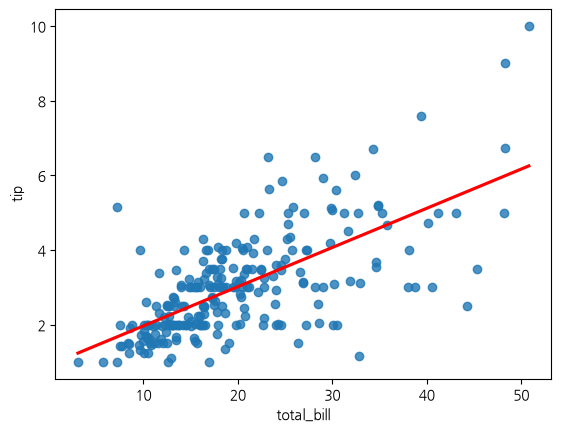

In [69]:
sns.regplot(data = tips, x = 'total_bill', y = 'tip', ci = None, line_kws =  {'color' : 'red'})

In [86]:
X = tips['total_bill'].values
y = tips['tip'].values

# 반복문을 이용해서 선형 회귀 구하기
a_values = np.linspace(0,2,100)
b_values = np.linspace(0,5,100)

best_a, best_b = None, None
min_error = float("inf")

for a in a_values:
  for b in b_values:
    y_hat = a*X + b
    error = np.sum(np.abs(y - y_hat))

    if error < min_error:
      min_error = error
      best_a, best_b = a, b

print(best_a, best_b, min_error)

0.12121212121212122 0.5555555555555556 179.96868686868686


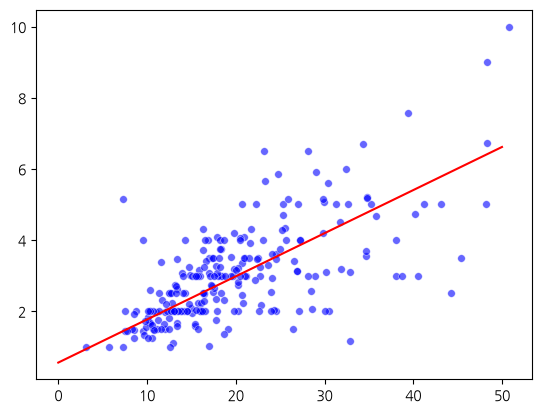

In [87]:
sns.scatterplot(x = X, y = y, s = 30, color = 'blue', alpha = 0.6)

x_line = np.linspace(0,50,100)
y_line = best_a * x_line + best_b
plt.plot(x_line, y_line, color = 'red')
plt.show()

In [ ]:
X = tips['total_bill'].values
y = tips['tip'].values

# 반복문을 이용해서 선형 회귀 구하기
a_values = np.linspace(0,2,100)
b_values = np.linspace(0,5,100)

best_a, best_b = None, None
min_error = float("inf")

# MAE
for a in a_values:
  for b in b_values:
    y_hat = a*X + b
    # error = np.sum(np.abs(y - y_hat))
    error = np.mean(np.abs(y - y_hat))

    if error < min_error:
      min_error = error
      best_a, best_b = a, b

print(best_a, best_b, min_error)

0.12121212121212122 0.5555555555555556 0.7375765855274051


In [89]:
# MSE
from sklearn.metrics import mean_squared_error

X = tips['total_bill'].values
y = tips['tip'].values

# 반복문을 이용해서 선형 회귀 구하기
a_values = np.linspace(0,2,100)
b_values = np.linspace(0,5,100)

best_a, best_b = None, None
min_error = float("inf")

# MAE
for a in a_values:
  for b in b_values:
    y_hat = a*X + b
    # error = np.sum(np.abs(y - y_hat))
    error = np.mean(np.abs(y - y_hat) ** 2)

    if error < min_error:
      min_error = error
      best_a, best_b = a, b

print(best_a, best_b, min_error)

0.10101010101010102 1.0101010101010102 1.0373996209821346


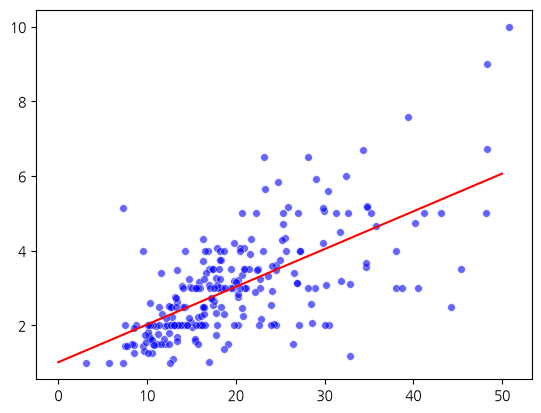

In [90]:
sns.scatterplot(x = X, y = y, s = 30, color = 'blue', alpha = 0.6)

x_line = np.linspace(0,50,100)
y_line = best_a * x_line + best_b
plt.plot(x_line, y_line, color = 'red')
plt.show()

# Gradient Descent

a : 0.20181821514917125, b : 0.9475464478938816
Epoch : 0, MSE = 5.5485, a = 0.1557, b = 0.9456
Epoch : 100, MSE = 1.0361, a = 0.1041, b = 0.9430
Epoch : 200, MSE = 1.0361, a = 0.1041, b = 0.9427
Epoch : 300, MSE = 1.0361, a = 0.1041, b = 0.9423
Epoch : 400, MSE = 1.0361, a = 0.1041, b = 0.9419
Epoch : 500, MSE = 1.0361, a = 0.1041, b = 0.9416
Epoch : 600, MSE = 1.0361, a = 0.1041, b = 0.9412
Epoch : 700, MSE = 1.0361, a = 0.1042, b = 0.9409
Epoch : 800, MSE = 1.0361, a = 0.1042, b = 0.9405
Epoch : 900, MSE = 1.0361, a = 0.1042, b = 0.9402


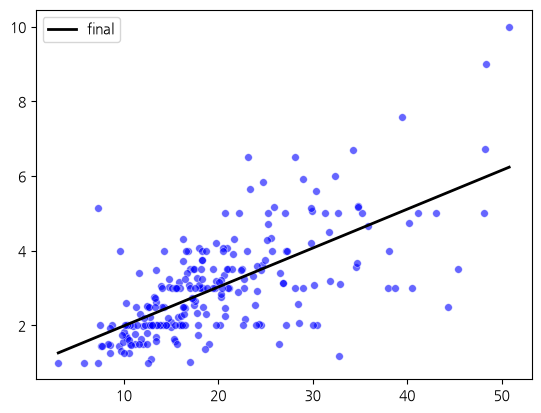

In [98]:
X = tips['total_bill'].values
y = tips['tip'].values

# 파라미터 초기화
a = np.random.randn()
b = np.random.randn()
print(f"a : {a}, b : {b}")

# 하이퍼 파라미터
lr = 0.001
epochs = 1000

for epoch in range(epochs):
  y_hat = a * X + b
  error = y_hat - y
  grad_a = np.mean(error * X)
  grad_b = np.mean(error)

  a -= grad_a * lr
  b -= grad_b * lr

  if epoch % 100 == 0:
    mse = np.mean(np.abs(y - y_hat) ** 2)
    print(f"Epoch : {epoch}, MSE = {mse:.4f}, a = {a:.4f}, b = {b:.4f}")

x_line = np.linspace(X.min(), X.max(), 100)
y_line = a * x_line + b
plt.plot(x_line, y_line, color='black', linewidth=2, label="final")
sns.scatterplot(x = X, y = y, s = 30, color = 'blue', alpha = 0.6)
plt.show()
